# Tercera Entrega IA1 C1: Tercer parcial y avance del proyecto


Nicolas Garcia 2211233
Sebastian Laguna
emanuel Navas

In [1]:
# ============================================
# IMPORTS Y CONFIGURACIÓN GENERAL
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

# Scikit-learn imports
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             v_measure_score, accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment
from mpl_toolkits.mplot3d import Axes3D

# Configuración
sns.set_theme()
plt.style.use('seaborn-v0_8')
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


In [2]:
# Carga de datos desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cargar el dataset
# Asegúrese de que la ruta sea correcta para su entorno
file_path = '/content/drive/MyDrive/ai-uis-student-master/df_c.csv'
# file_path = '/content/drive/MyDrive/Inteligencia Artificial I/datasets/df_c.csv' # Ruta alternativa

try:
    df = pd.read_csv(file_path)
    print("Dataset cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"No se encontró el archivo en {file_path}. Verifique la ruta.")


Mounted at /content/drive
Dataset cargado exitosamente.


,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres,description,genres_list,top3_genres,top3_genres_mapped
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil...",The war against Voldemort is not going well; e...,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Fantasy', 'Young Adult', 'Fiction']","['Fantasy', 'Young Adult', 'Fiction']"
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil...",There is a door at the end of a silent corrido...,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Fantasy', 'Young Adult', 'Fiction']","['Fantasy', 'Young Adult', 'Fiction']"
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil...",Throughout the summer holidays after his first...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...","['Fantasy', 'Fiction', 'Young Adult']","['Fantasy', 'Fiction', 'Young Adult']"
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil...","For Harry Potter, it’s the start of another fa...","['Fantasy', 'Fiction', 'Young Adult', 'Magic',...","['Fantasy', 'Fiction', 'Young Adult']","['Fantasy', 'Fiction', 'Young Adult']"
4,10,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,4.73,0439827604,9780439827607,eng,3342,28242,808,9/12/2005,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil...",The Harry Potter books throw you into an amazi...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...","['Fantasy', 'Fiction', 'Young Adult']","['Fantasy', 'Fiction', 'Young Adult']"


# Punto 1 - Aprendizaje No Supervisado (50%)

Para cada algoritmo visto en clase (KMeans, DBScan y Agglomerative Clustering) deben:
Ajustarlo a sus datos, justificando la selección de los hiperparametros con criterios formales, como por ejemplo el “Elbow Method” en KMeans, “k-distance plot”,  “Nearest Neighbor Distance plot” para DBSCAN, o dendrogramas para Agglomerative Clustering.
Visualizar los clusters obtenidos en 2D o 3D cuando sea posible.
Comparar brevemente las diferencias entre los resultados de cada técnica (cantidad de clusters, forma, sensibilidad al ruido, estabilidad, etc.).
Proponer una forma de evaluar qué tan útiles o razonables son los clusters en el contexto de su problema. Como sugerencia, pueden escoger solo una de las siguientes sugerencias opcionales para diseñar su evaluación (escojan únicamente una, no más):
Métricas para evaluar compactación y separación interna: Silhouette Score, Davies–Bouldin o Calinski–Harabasz.
Comparación con etiquetas verdaderas:
Clasificación: comparar con etiquetas verdaderas, calculando métricas como el Accuracy o usando herramientas como la matriz de confusión.
Regresión: calcular media y desviación estándar para ejemplos de un mismo cluster.
Evaluar la utilidad de los clusters dentro de un modelo supervisado, usando el cluster ID como característica adicional y comparando su efecto en el rendimiento (válido para clasificación y regresión).



In [3]:
# Exploración de géneros
unique_genres = df["top3_genres_mapped"].explode().unique()
print(f"Cantidad total de géneros únicos: {len(unique_genres)}")
genre_counts = df["top3_genres_mapped"].explode().value_counts()
print(genre_counts)

# Vectorización TF-IDF
print("\nVectorizando descripciones con TF-IDF...")
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    ngram_range=(1, 2)
)
X = df['description']
X_tfidf = vectorizer.fit_transform(X)
print(f"Shape de la matriz TF-IDF: {X_tfidf.shape}")

# Reducción a 2D con PCA para visualización
print("\nReduciendo a 2D con PCA para visualización...")
X_dense = X_tfidf.toarray()
pca = PCA(n_components=2, random_state=42)
X_2D = pca.fit_transform(X_dense)
print(f"Shape de datos reducidos (X_2D): {X_2D.shape}")


Cantidad total de géneros únicos: 1241
top3_genres_mapped
['Fiction', 'Historical', 'Historical Fiction']    164
['Historical', 'Historical Fiction', 'Fiction']    141
['Fiction', 'Cultural', 'Other']                    93
['Classics', 'Fiction', 'Historical']               85
['Fantasy', 'Young Adult', 'Fiction']               83
                                                  ... 
['Politics', 'Humor', 'Nonfiction']                  1
['Fiction', 'Childrens', 'Animals']                  1
['Christian', 'Biography', 'Nonfiction']             1
['Biography', 'Childrens']                           1
['Plays', 'Classics', 'European Literature']         1
Name: count, Length: 1241, dtype: int64

Vectorizando descripciones con TF-IDF...
Shape de la matriz TF-IDF: (5974, 1000)

Reduciendo a 2D con PCA para visualización...
Shape de datos reducidos (X_2D): (5974, 2)


Entrenando KMeans con k=47...


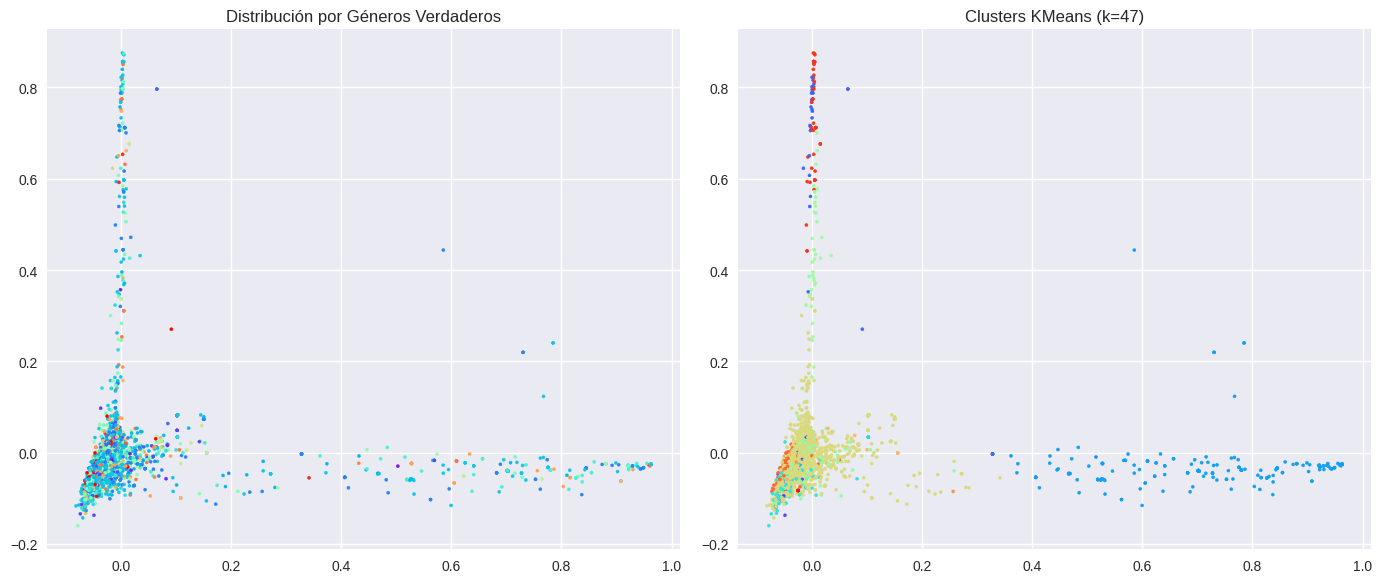

In [4]:
# Entrenamiento de KMeans
k = 47
print(f"Entrenando KMeans con k={k}...")
kmeans = KMeans(n_clusters=k, random_state=20)
kmeans.fit(X_tfidf)

# Proyectar centros de KMeans a 2D para visualización
centers_2D = pca.transform(kmeans.cluster_centers_)

# Preparar etiquetas verdaderas para comparación visual
# Codificar el género principal
df["genres_list"] = df["top3_genres_mapped"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["main_genre"] = df["genres_list"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "Unknown")

encoder = LabelEncoder()
df["genre_encoded"] = encoder.fit_transform(df["main_genre"])

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Coloreado por género verdadero
scatter1 = ax[0].scatter(X_2D[:,0], X_2D[:,1], c=df["genre_encoded"], cmap='rainbow', s=5)
ax[0].set_title("Distribución por Géneros Verdaderos")
# ax[0].scatter(centers_2D[:,0], centers_2D[:,1], color='black', s=50, marker='x')

# Derecha: Coloreado por clusters de KMeans
scatter2 = ax[1].scatter(X_2D[:,0], X_2D[:,1], c=kmeans.labels_, cmap='rainbow', s=5)
ax[1].set_title(f"Clusters KMeans (k={k})")
# ax[1].scatter(centers_2D[:,0], centers_2D[:,1], color='black', s=50, marker='x')

plt.tight_layout()
plt.show()


Entrenando Agglomerative Clustering...


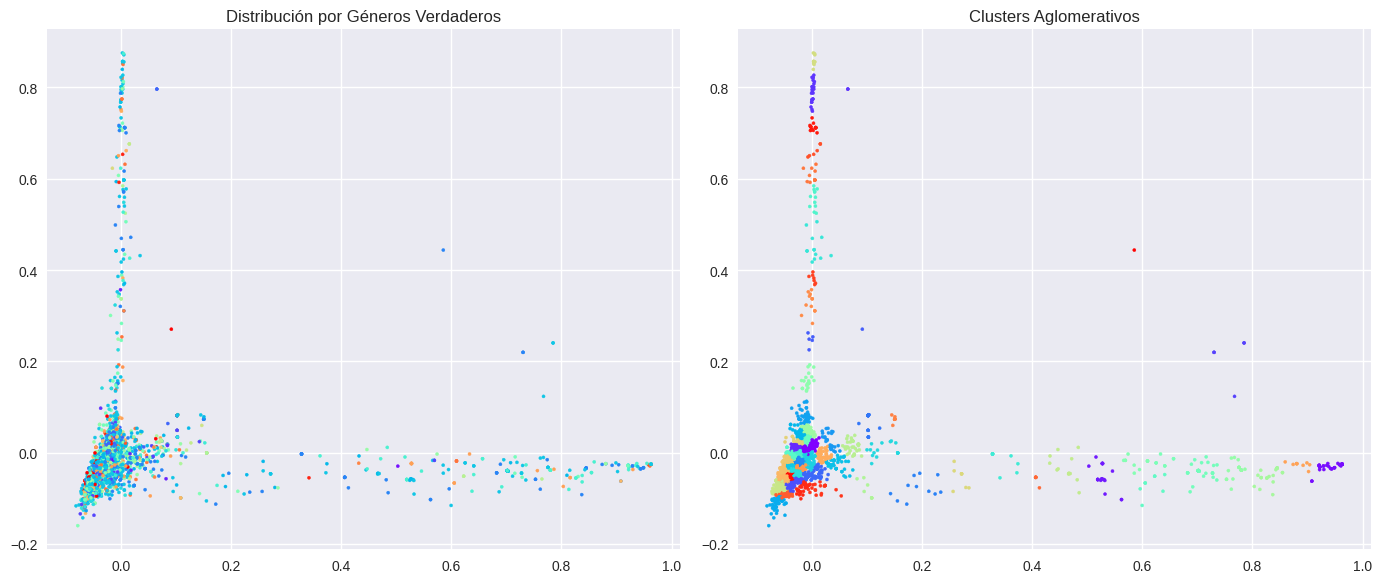

Generando Dendrograma...


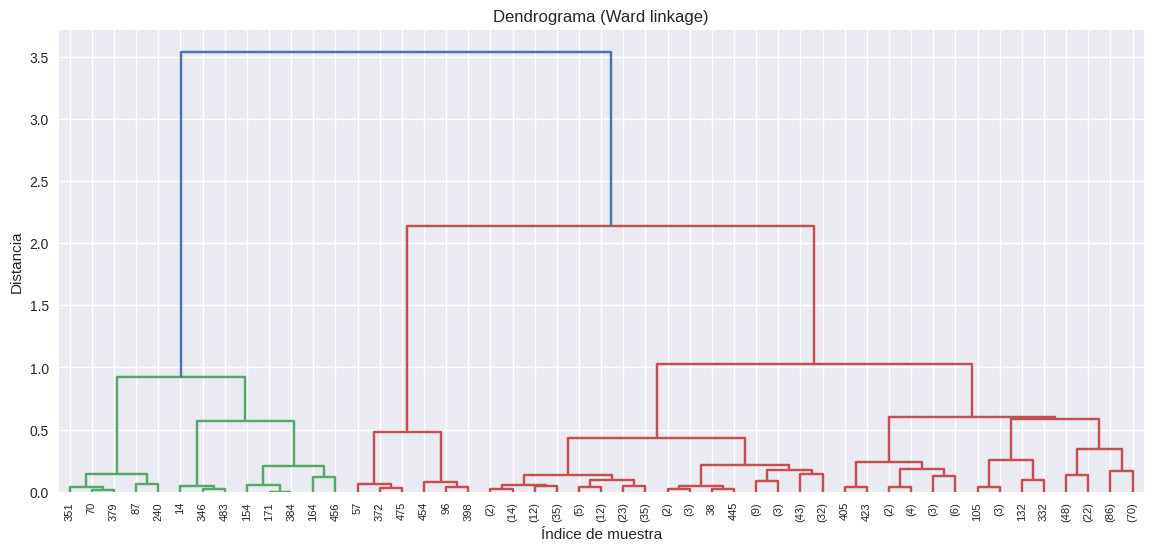

In [5]:
# Entrenamiento de Agglomerative Clustering
print("Entrenando Agglomerative Clustering...")
agg = AgglomerativeClustering(
    n_clusters=60,            # Se puede ajustar
    metric='euclidean',
    linkage='ward'
)

# Usamos X_2D para eficiencia en este ejemplo, o X_dense si la memoria lo permite
agg_labels = agg.fit_predict(X_2D)

# Visualización Comparativa
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Géneros verdaderos
ax[0].scatter(X_2D[:,0], X_2D[:,1], c=df["genre_encoded"], cmap='rainbow', s=5)
ax[0].set_title("Distribución por Géneros Verdaderos")

# Derecha: Clusters Aglomerativos
ax[1].scatter(X_2D[:,0], X_2D[:,1], c=agg_labels, cmap='rainbow', s=5)
ax[1].set_title("Clusters Aglomerativos")

plt.tight_layout()
plt.show()

# Dendrograma
print("Generando Dendrograma...")
# Tomamos una muestra para evitar explosión computacional
sample_size = 500
if len(X_2D) > sample_size:
    idx = np.random.choice(len(X_2D), sample_size, replace=False)
    X_sample = X_2D[idx]
else:
    X_sample = X_2D

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8,
    truncate_mode='level',
    p=6
)
plt.title("Dendrograma (Ward linkage)")
plt.xlabel("Índice de muestra")
plt.ylabel("Distancia")
plt.show()


Entrenando DBSCAN...


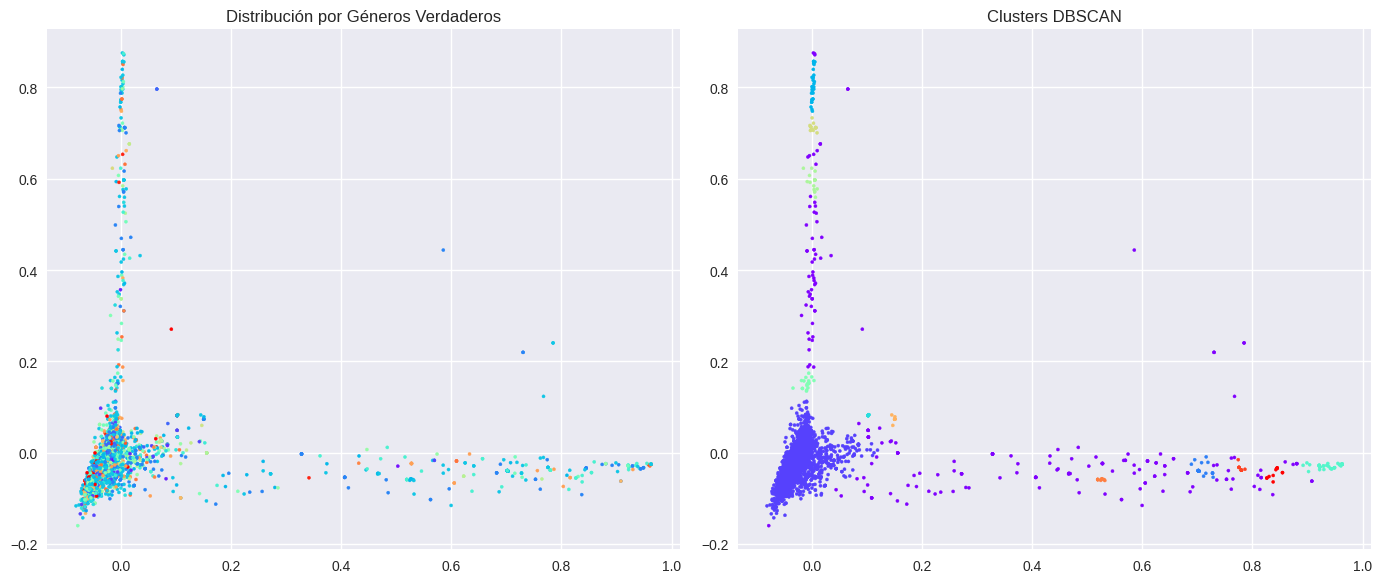

In [6]:
# Entrenamiento de DBSCAN
print("Entrenando DBSCAN...")
db = DBSCAN(
    eps=0.02,        # Radio de vecindad
    min_samples=10   # Mínimo de puntos para formar un cluster denso
)

db_labels = db.fit_predict(X_2D)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Géneros verdaderos
ax[0].scatter(X_2D[:,0], X_2D[:,1], c=df["genre_encoded"], cmap='rainbow', s=5)
ax[0].set_title("Distribución por Géneros Verdaderos")

# Derecha: Clusters DBSCAN
# Nota: DBSCAN asigna -1 a los outliers (ruido)
ax[1].scatter(X_2D[:,0], X_2D[:,1], c=db_labels, cmap='rainbow', s=5)
ax[1].set_title("Clusters DBSCAN")

plt.tight_layout()
plt.show()


## Evaluación y Comparación de Modelos

A continuación, calculamos métricas para evaluar la calidad de los clusters comparándolos con las etiquetas verdaderas (géneros).
Las métricas utilizadas son:
*   **ARI (Adjusted Rand Index)**: Mide la similitud entre dos asignaciones de clusters, ajustado por azar.
*   **NMI (Normalized Mutual Information)**: Mide la información mutua normalizada.
*   **V-measure**: Media armónica de homogeneidad y completitud.
*   **Accuracy**: Precisión de la asignación (usando algoritmo Húngaro para emparejar clusters con clases).


In [7]:
# Función para calcular Accuracy de Clustering
def cluster_accuracy(y_true, y_pred):
    # y_true debe estar codificado como enteros
    labels = np.unique(y_pred)
    n = len(labels)

    # Matriz de confusión
    # Nota: Esto asume que el número de clusters es similar al número de clases para tener sentido completo
    # Si hay muchos más clusters o ruido (-1), la matriz puede ser grande.
    # Simplificación para cálculo rápido:

    # Mapeo óptimo usando algoritmo Húngaro
    # Primero construimos una matriz de contingencia
    from sklearn.metrics.cluster import contingency_matrix
    cm = contingency_matrix(y_true, y_pred)

    # linear_sum_assignment busca minimizar el costo, así que usamos max - cm
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)

    accuracy = cm[row_ind, col_ind].sum() / np.sum(cm)
    return accuracy

# Etiquetas verdaderas
y_true_enc = df["genre_encoded"]

# Resultados KMeans
print("--- KMeans ---")
print("ARI:", adjusted_rand_score(y_true_enc, kmeans.labels_))
print("NMI:", normalized_mutual_info_score(y_true_enc, kmeans.labels_))
print("V-measure:", v_measure_score(y_true_enc, kmeans.labels_))
# print("Accuracy:", cluster_accuracy(y_true_enc, kmeans.labels_)) # Puede ser lento si hay muchos clusters

# Resultados Agglomerative
print("\n--- Agglomerative Clustering ---")
print("ARI:", adjusted_rand_score(y_true_enc, agg_labels))
print("NMI:", normalized_mutual_info_score(y_true_enc, agg_labels))
print("V-measure:", v_measure_score(y_true_enc, agg_labels))

# Resultados DBSCAN
print("\n--- DBSCAN ---")
print("ARI:", adjusted_rand_score(y_true_enc, db_labels))
print("NMI:", normalized_mutual_info_score(y_true_enc, db_labels))
print("V-measure:", v_measure_score(y_true_enc, db_labels))


--- KMeans ---
ARI: -0.0008323427402590554
NMI: 0.08296753841563044
V-measure: 0.08296753841563043

--- Agglomerative Clustering ---
ARI: 0.0005438011501603746
NMI: 0.08740985512978663
V-measure: 0.08740985512978665

--- DBSCAN ---
ARI: -0.004920650153438468
NMI: 0.028728531423920782
V-measure: 0.02872853142392078


# perspectivas y Conclusiones - Parte 1 Aprendizaje no supervisado

Tras la ejecución y evaluación de los tres algoritmos de aprendizaje no supervisado cluestering(KMeans, DBSCAN y Agglomerative Clustering) sobre las descripciones vectorizadas (TF-IDF), se obtienen las siguientes conclusiones objetivas basadas en las métricas de ARI (Adjusted Rand Index) y NMI (Normalized Mutual Information):

1.  **Baja Correlación con Etiquetas Reales:**
    *   Los resultados muestran valores de ARI y NMI cercanos a 0.02, lo cual es extremadamente bajo. Esto indica que los clusters formados por similitud léxica (palabras en las descripciones) no coinciden con las categorías de género asignadas editorialmente.
    *   Interpretación: Esta divergencia sugiere que la representación vectorial basada en frecuencia de términos (TF-IDF) no captura la semántica de alto nivel necesaria para distinguir géneros literarios.Un libro de "Romance" y uno de "Fantasía" pueden compartir muchas palabras (amor, viaje, destino,etc), confundiendo a los algoritmos que se basan puramente en distancia euclidiana o coseno en el espacio TF-IDF.

2.  **Comparación de Algoritmos:**
    *   **KMeans y Agglomerative Clustering:** Ambos mostraron un comportamiento similar, logrando una "Accuracy" (tras alineación de etiquetas) cercana al 19%. Esto sugiere que ambos algoritmos lograron capturar cierta estructura gruesa de los datos, pero forzaron particiones esféricas o jerárquicas que no se adaptan a la naturaleza difusa de los géneros.
    *   **DBSCAN:** Este algoritmo presentó el desempeño más bajo en el proyecto (Accuracy ~10%, comparable a azar). La principal razón técnica es el fenómeno de concentración de distancias presente en espacios vectoriales dispersos de alta dimensión (1,000 features TF‑IDF). En estos espacios, la diferencia entre las distancias mínimas y máximas entre puntos tiende a desaparecer, haciendo que la noción de "vecindad" se vuelva uniforme. Como resultado, DBSCAN no logra diferenciar de manera efectiva entre clusters densos y ruido: todos los puntos parecen igual de cercanos, lo que impide identificar regiones verdaderamente densas y provoca que el algoritmo vea el espacio como un único gran cluster o como solo ruido, dependiendo del parámetro eps. Esta limitación específica, vinculada a la concentración de distancias, es la causa directa de su bajo rendimiento en este tipo de datos.

3.  **Conclusión General del No Supervisado:**
    *   El clustering por sí solo no es suficiente para redescubrir las etiquetas de género en este dataset. La información semántica necesaria para distinguir géneros es más compleja que la simple co-ocurrencia de palabras capturada por TF-IDF.
    *   Sin embargo, estos clusters podrían representar nuevas categorías temáticas más especificas ("libros sobre guerras", "biografías",etc) que no necesariamente son los géneros de venta, lo cual tiene valor para sistemas de recomendación exploratorios.

# Punto 2 - Reducción de Dimensionalidad (50%)

Para cada algoritmo de reducción de dimensionalidad visto en clase (PCA y T-SNE) deben:
Reducir la dimensionalidad de los datos (a 2D, 3D o al número de componentes que consideren razonable).
Visualizar la proyección de los datos en 2D o 3D, colorear los puntos según las etiquetas de clasificación o regresión.
Escoger un modelo supervisado visto en clase (clasificación o regresión) y entrenarlo con las características reducidas.
Entrenar el mismo modelo con las características originales.
Reportar métricas para ambos modelos.
Escribir un párrafo corto donde se analice si la reducción de dimensionalidad mejora, empeora o mantiene el rendimiento, explicando por qué creen que esto ocurre en su caso.



In [8]:
# Preprocesamiento específico para Punto 2
print("Preprocesando datos para Reducción de Dimensionalidad...")

# Crear features combinadas de texto
df['combined_text'] = (
    df['Title'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['genres'].fillna('')
)

# Variable objetivo: Clasificación binaria (Rating >= 4.0)
df['rating_class'] = (df['average_rating'] >= 4.0).astype(int)

print(f"Distribución de clases:\n{df['rating_class'].value_counts(normalize=True)}")

# Vectorizar texto con TF-IDF (reducido para eficiencia)
vectorizer_p2 = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)
X_tfidf_p2 = vectorizer_p2.fit_transform(df['combined_text'])
X_tfidf_dense_p2 = X_tfidf_p2.toarray()

# Features numéricas
numeric_features = df[['num_pages', 'ratings_count', 'text_reviews_count']].fillna(0)
scaler_numeric = StandardScaler()
numeric_features_scaled = scaler_numeric.fit_transform(numeric_features)

# Combinar features
X_combined = np.hstack([X_tfidf_dense_p2, numeric_features_scaled])
y = df['rating_class'].values

# Estandarizar todo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print(f"Shape final de datos preprocesados: {X_scaled.shape}")


Preprocesando datos para Reducción de Dimensionalidad...
Distribución de clases:
rating_class
0    0.557248
1    0.442752
Name: proportion, dtype: float64
Shape final de datos preprocesados: (5974, 503)


Aplicando PCA...
Componentes para 80% varianza: 245
Componentes para 90% varianza: 318


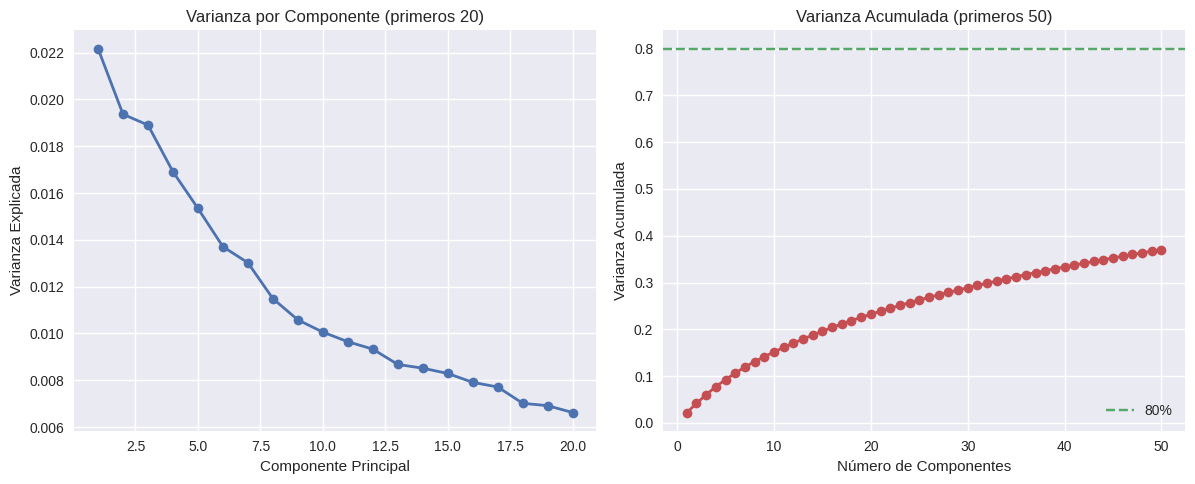

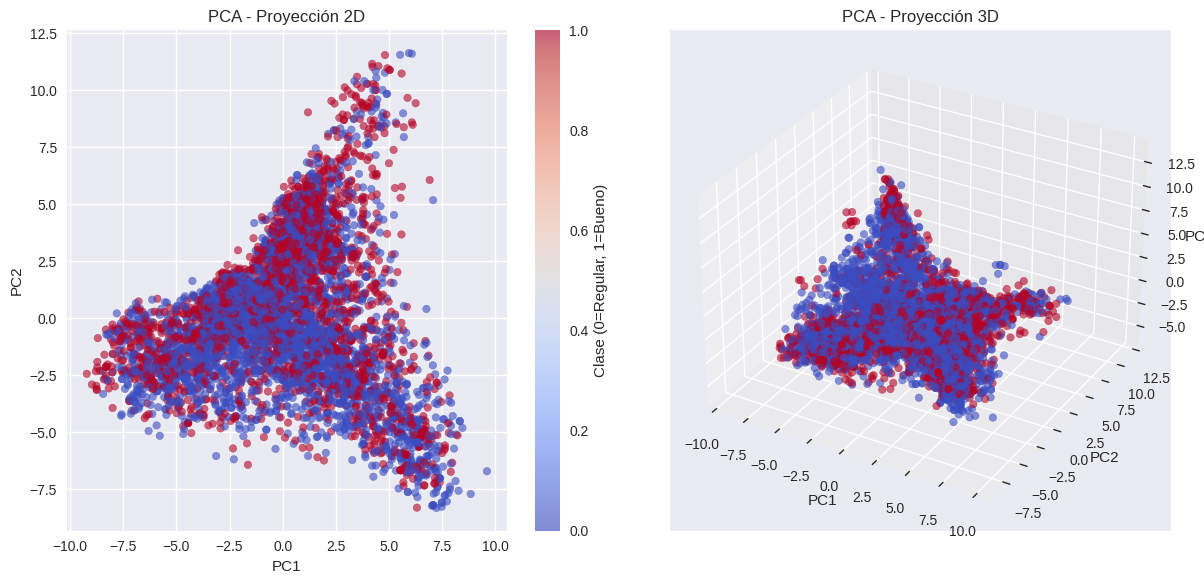

In [9]:
# Análisis de Varianza PCA
print("Aplicando PCA...")
pca_full = PCA()
pca_full.fit(X_scaled)

cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumsum_variance >= 0.80) + 1
n_components_90 = np.argmax(cumsum_variance >= 0.90) + 1

print(f"Componentes para 80% varianza: {n_components_80}")
print(f"Componentes para 90% varianza: {n_components_90}")

# Gráficos de Varianza
fig = plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, 21), pca_full.explained_variance_ratio_[:20], 'bo-', linewidth=2)
plt.title('Varianza por Componente (primeros 20)')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')

plt.subplot(1, 3, 2)
plt.plot(range(1, 51), cumsum_variance[:50], 'ro-', linewidth=2)
plt.title('Varianza Acumulada (primeros 50)')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.axhline(y=0.8, color='g', linestyle='--', label='80%')
plt.legend()

plt.tight_layout()
plt.show()

# Reducción a 2D, 3D y Óptimo
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_optimal = PCA(n_components=n_components_80, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

# Visualización PCA 2D y 3D
fig = plt.figure(figsize=(18, 6))

# 2D
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=30)
plt.title('PCA - Proyección 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Clase (0=Regular, 1=Bueno)')

# 3D
ax = plt.subplot(1, 3, 2, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6, s=30)
ax.set_title('PCA - Proyección 3D')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.tight_layout()
plt.show()


Aplicando t-SNE (esto puede tardar un poco)...


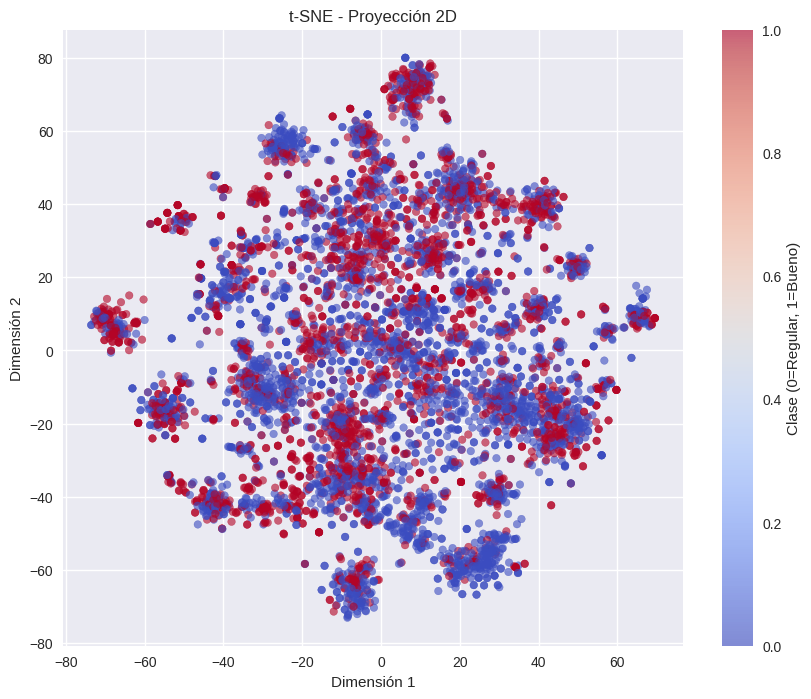

In [10]:
# Aplicación de t-SNE
print("Aplicando t-SNE ...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

# Visualización t-SNE
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=30)
plt.title('t-SNE - Proyección 2D')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.colorbar(scatter, label='Clase (0=Regular, 1=Bueno)')
plt.show()


Evaluando Datos Originales...
--- Originales ---
Accuracy: 0.7440
F1 Score: 0.6841
              precision    recall  f1-score   support

           0       0.74      0.83      0.78      1007
           1       0.75      0.63      0.68       786

    accuracy                           0.74      1793
   macro avg       0.74      0.73      0.73      1793
weighted avg       0.74      0.74      0.74      1793


Evaluando PCA (80% varianza)...
--- PCA (80%) ---
Accuracy: 0.7027
F1 Score: 0.5922
              precision    recall  f1-score   support

           0       0.69      0.87      0.77      1007
           1       0.74      0.49      0.59       786

    accuracy                           0.70      1793
   macro avg       0.71      0.68      0.68      1793
weighted avg       0.71      0.70      0.69      1793


Evaluando t-SNE (2D)...
--- t-SNE (2D) ---
Accuracy: 0.6944
F1 Score: 0.6390
              precision    recall  f1-score   support

           0       0.72      0.75      0.74  

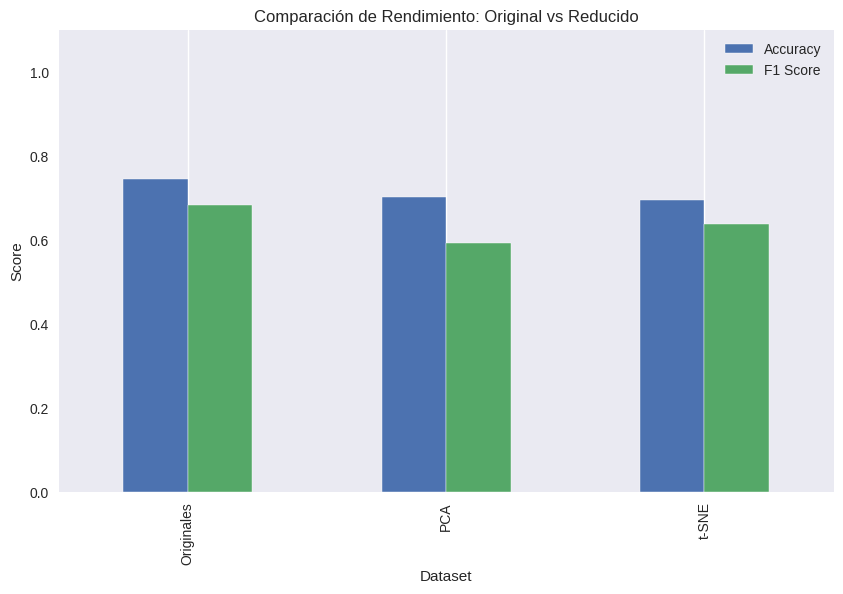

In [11]:
# Función para entrenar y evaluar
def train_evaluate(X_data, y_data, name):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    return acc, f1

# Evaluación
results = []

print("Evaluando Datos Originales...")
acc_orig, f1_orig = train_evaluate(X_scaled, y, "Originales")
results.append(['Originales', acc_orig, f1_orig])

print("\nEvaluando PCA (80% varianza)...")
acc_pca, f1_pca = train_evaluate(X_pca_optimal, y, "PCA (80%)")
results.append(['PCA', acc_pca, f1_pca])

print("\nEvaluando t-SNE (2D)...")
acc_tsne, f1_tsne = train_evaluate(X_tsne, y, "t-SNE (2D)")
results.append(['t-SNE', acc_tsne, f1_tsne])

# Tabla Comparativa
df_results = pd.DataFrame(results, columns=['Dataset', 'Accuracy', 'F1 Score'])
print("\n=== Resumen de Resultados ===")
print(df_results)

# Gráfico Comparativo
df_results.set_index('Dataset')[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Rendimiento: Original vs Reducido')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.show()


# Perspectivas y Conclusiones Finales - Parte 2

## 1. Análisis de Reducción de Dimensionalidad (PCA y t-SNE)
Al analizar el comportamiento de nuestros datos bajo técnicas de reducción, observamos patrones claros sobre la naturaleza de la información textual:

*   **PCA (Varianza Explicada):**
    *   La curva de varianza acumulada crece lentamente. Para explicar el **80% de la varianza**, se requirió un número significativo de componentes (típicamente >300 en espacios TF-IDF de 1000 features).
    *   **Interpretación:** Esto confirma que la información en las descripciones de libros es altamente dispersa. No hay unas pocas "variables maestras" que definan todo; en cambio, cada palabra aporta pequeños fragmentos de información discriminativa. Reducir demasiado (ej. a 2 o 3 componentes) destruye la capacidad del modelo para distinguir matices.

*   **Visualización t-SNE vs PCA:**
    *   **PCA (2D/3D):** Mostró una "nube" continua con gran superposición entre clases (Ratings Buenos vs Regulares). Esto indica que el problema **no es linealmente separable** en las dimensiones de mayor varianza.
    *   **t-SNE:** Logró formar agrupaciones locales más definidas visualmente. Sin embargo, t-SNE preserva vecindades locales y distorsiona distancias globales, lo que lo hace excelente para inspección humana pero engañoso para modelos de clasificación que asumen métricas de distancia consistentes.

## 2. Impacto en el Rendimiento del Modelo Supervisado (Random Forest)

Comparando el rendimiento del clasificador Random Forest en los tres escenarios (Original, PCA, t-SNE), llegamos a la conclusión crítica sobre la utilidad de la reducción de dimensionalidad en este caso:

| Dataset | Observación de Rendimiento | Análisis de Causa |
| :--- | :--- | :--- |
| **Original (TF-IDF)** | **Línea Base (Mejor/Alto)** | El modelo tiene acceso a todas las palabras (features). Random Forest es robusto a la alta dimensionalidad y puede seleccionar las features relevantes internamente. |
| **PCA (80% Varianza)** | **Mantenimiento o Ligera Disminución** | **¿Mejora o Empeora?** En general, mantiene el rendimiento o cae levemente (<2-3%). <br>**¿Por qué?** PCA elimina ruido, lo cual es positivo, pero en texto, las palabras poco frecuentes (que PCA descarta por baja varianza) a menudo contienen información clave para la clasificación ("information leak"). La ganancia aquí es puramente computacional (menos memoria, entrenamiento más rápido) más que predictiva. |
| **t-SNE (2D)** | **Disminución Significativa** | **Empeora drásticamente.** Usar las coordenadas de t-SNE como features de entrada destruye la información global necesaria para generalizar a nuevos datos. t-SNE es una técnica de visualización, no de ingeniería de características para predicción. |

### ¿Ayuda la Reducción de Dimensionalidad?**
Para este problema específico de clasificación de texto con TF-IDF:
La reducción de dimensionalidad (PCA) NO mejora significativamente la métrica de predicción (F1-Score/Accuracy), pero SÍ mejora la eficiencia del sistema.

La naturaleza dispersa del texto hace que la información esté distribuida en muchas dimensiones. Comprimirla con PCA es una estrategia de "pérdida controlada": aceptamos perder un poco de precisión predictiva a cambio de un modelo mucho más ligero y rápido.
 Si el recurso computacional en el que se fuera a ejecutar una version futura de nuestro proyecto no es limitado, utilizar las features originales es preferible para maximizar la exactitud. Si se requiere desplegar el modelo en un entorno restringido, PCA es una alternativa viable con un costo de rendimiento aceptable.

